In [1]:
#  Imports and load data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option("display.max_columns", None)

stores = pd.read_csv("data/dim_stores.csv")
skus = pd.read_csv("data/dim_skus.csv")
suppliers = pd.read_csv(
    "data/dim_suppliers.csv",
    na_values=["N/A", "missing", "--", "NA", "null"],
    keep_default_na=True
)
events = pd.read_csv("data/dim_events.csv")
inventory = pd.read_csv("data/fact_inventory_daily.csv")

inventory["date"] = pd.to_datetime(inventory["date"])
events["date"] = pd.to_datetime(events["date"])

In [2]:
# Verify locked sanity checks

print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)

print("\nTarget distribution:")
print(inventory["stockout_risk"].value_counts())
print((inventory["stockout_risk"].value_counts(normalize=True) * 100).round(2))

print("\nDate range:")
print(inventory["date"].min(), "to", inventory["date"].max())
print("Unique dates:", inventory["date"].nunique())

print("\nMissing lead_time_days_actual:")
print(inventory["lead_time_days_actual"].isna().sum())

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)

Target distribution:
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64

Date range:
2026-10-01 00:00:00 to 2026-10-30 00:00:00
Unique dates: 30

Missing lead_time_days_actual:
19899


In [3]:
# Clean city and reliability fields

stores["city_display"] = stores["city_display"].str.strip().str.title()

suppliers["reliability_score"] = pd.to_numeric(
    suppliers["reliability_score"],
    errors="coerce"
)

print(suppliers["reliability_score"].isna().sum())

3


In [4]:
# Check supplier IDs before joining

supplier_check = inventory[["sku_id", "supplier_id"]].drop_duplicates().merge(
    skus[["sku_id", "supplier_id"]],
    on="sku_id",
    how="left",
    suffixes=("_fact", "_sku"),
    validate="m:1"
)

mismatch = supplier_check[
    supplier_check["supplier_id_fact"] != supplier_check["supplier_id_sku"]
]

print("Supplier-ID mismatches:", len(mismatch))
display(mismatch.head())

Supplier-ID mismatches: 0


,sku_id,supplier_id_fact,supplier_id_sku


In [5]:
# Merge all five tables correctly

sku_columns = skus.drop(columns=["supplier_id"])

df = (
    inventory
    .merge(stores, on="store_id", how="left", validate="m:1")
    .merge(sku_columns, on="sku_id", how="left", validate="m:1")
    .merge(suppliers, on="supplier_id", how="left", validate="m:1")
    .merge(events, on="date", how="left", validate="m:1")
)

print("Final shape:", df.shape)
print("Duplicate column names:", df.columns[df.columns.duplicated()].tolist())

assert len(df) == 21600
assert not df.columns.duplicated().any()

Final shape: (21600, 39)
Duplicate column names: []


In [6]:
# Impute supplier reliability

category_reliability = (
    df.groupby("category")["reliability_score"]
    .transform("median")
)

df["reliability_score"] = df["reliability_score"].fillna(category_reliability)

df["reliability_score"] = df["reliability_score"].fillna(
    df["reliability_score"].median()
)

df["supplier_reliability_risk"] = 1 - df["reliability_score"]

print(df["reliability_score"].isna().sum())

0


In [7]:
# EDA sanity checks

festival_analysis = (
    df.groupby("is_festival_week")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

perishable_analysis = (
    df.groupby("is_perishable")["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

df["reliability_group"] = pd.cut(
    df["reliability_score"],
    bins=[-np.inf, 0.75, 0.85, np.inf],
    labels=["Low", "Mid", "High"],
    right=False
)

supplier_analysis = (
    df.groupby("reliability_group", observed=True)["stockout_risk"]
    .apply(lambda x: (x == "Imminent").mean() * 100)
)

print("Festival effect:\n", festival_analysis.round(2))
print("\nPerishable effect:\n", perishable_analysis.round(2))
print("\nSupplier reliability effect:\n", supplier_analysis.round(2))

Festival effect:
 is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64

Perishable effect:
 is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64

Supplier reliability effect:
 reliability_group
Low     13.51
Mid      3.26
High     5.03
Name: stockout_risk, dtype: float64


Note: Supplier reliability results are calculated after treating missing reliability values using category-level median imputation. Therefore, the reliability-group percentages may differ slightly from the raw locked sanity figures in the project specification.

In [8]:
# Feature engineering

df = df.sort_values(["store_id", "sku_id", "date"]).copy()

df["day_of_month"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["is_festival_event"] = (df["event_type"] == "festival").astype(int)
df["is_promo_event"] = (df["event_type"] == "promo").astype(int)

festival_start = df.loc[df["event_type"] == "festival", "date"].min()

df["days_since_festival_start"] = np.where(
    df["date"] >= festival_start,
    (df["date"] - festival_start).dt.days,
    -1
)

df["reorder_gap"] = df["reorder_point"] - df["closing_stock"]

df["days_of_cover_ratio"] = (
    df["days_of_cover"] /
    df["lead_time_days_expected"].replace(0, np.nan)
)

df["stock_utilization"] = (
    df["units_sold"] /
    df["opening_stock"].replace(0, np.nan)
)

df["demand_gap"] = df["units_demanded"] - df["units_sold"]

df["is_perishable_flag"] = (df["is_perishable"] == "Y").astype(int)
df["festive_relevant_flag"] = (df["festive_relevant"] == "Y").astype(int)

df["reorder_flag"] = (df["reorder_placed"] == "Y").astype(int)

df["is_recent_reorder"] = (
    df.groupby(["store_id", "sku_id"])["reorder_flag"]
    .transform(lambda s: s.shift(1).rolling(3, min_periods=1).max())
    .fillna(0)
    .astype(int)
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [9]:
# Select features

numeric_features = [
    "opening_stock",
    "closing_stock",
    "reorder_point",
    "reorder_gap",
    "units_demanded",
    "units_sold",
    "demand_gap",
    "sales_velocity_7d",
    "days_of_cover",
    "days_of_cover_ratio",
    "stock_utilization",
    "lead_time_days_expected",
    "base_lead_time_days",
    "lead_time_variance_days",
    "reliability_score",
    "supplier_reliability_risk",
    "sqft",
    "opened_year",
    "baseline_daily_orders",
    "unit_price_inr",
    "shelf_life_days",
    "day_of_month",
    "day_of_week",
    "is_weekend",
    "is_festival_event",
    "is_promo_event",
    "days_since_festival_start",
    "is_perishable_flag",
    "festive_relevant_flag",
    "is_recent_reorder",
    "demand_multiplier_festive",
    "demand_multiplier_other"
]

categorical_features = [
    "category",
    "popularity_tier",
    "store_size",
    "city",
    "event_type"
]

features = numeric_features + categorical_features

X = df[features]
y = df["stockout_risk"]

In [10]:
# Use a time-based train/test split

train_mask = df["date"] <= "2026-10-23"
test_mask = df["date"] > "2026-10-23"

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Train period:", df.loc[train_mask, "date"].min(), "to", df.loc[train_mask, "date"].max())
print("Test period:", df.loc[test_mask, "date"].min(), "to", df.loc[test_mask, "date"].max())

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train period: 2026-10-01 00:00:00 to 2026-10-23 00:00:00
Test period: 2026-10-24 00:00:00 to 2026-10-30 00:00:00
Train shape: (16560, 37)
Test shape: (5040, 37)


In [11]:
# Build preprocessing and models

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="saga",
        class_weight="balanced",
        random_state=42
    ))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

In [12]:
# Evaluate all models

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Imminent Precision": precision_score(
            y_test, predictions,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        "Imminent Recall": recall_score(
            y_test, predictions,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        ),
        "Imminent F1": f1_score(
            y_test, predictions,
            labels=["Imminent"],
            average="macro",
            zero_division=0
        )
    }

    return result, predictions

baseline_result, baseline_pred = evaluate_model(
    "Majority Baseline", baseline_model,
    X_train, y_train, X_test, y_test
)

logistic_result, logistic_pred = evaluate_model(
    "Logistic Regression", logistic_model,
    X_train, y_train, X_test, y_test
)

rf_result, rf_pred = evaluate_model(
    "Random Forest", rf_model,
    X_train, y_train, X_test, y_test
)

comparison = pd.DataFrame([
    baseline_result,
    logistic_result,
    rf_result
])

display(comparison.round(3))

,Model,Accuracy,Imminent Precision,Imminent Recall,Imminent F1
0,Majority Baseline,0.623,0.000,0.000,0.000
1,Logistic Regression,0.795,0.442,0.994,0.611
2,Random Forest,0.927,0.908,0.600,0.723


              precision    recall  f1-score   support

     At-Risk       0.77      0.95      0.85      1126
    Imminent       0.91      0.60      0.72       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.93      5040
   macro avg       0.89      0.85      0.86      5040
weighted avg       0.93      0.93      0.92      5040



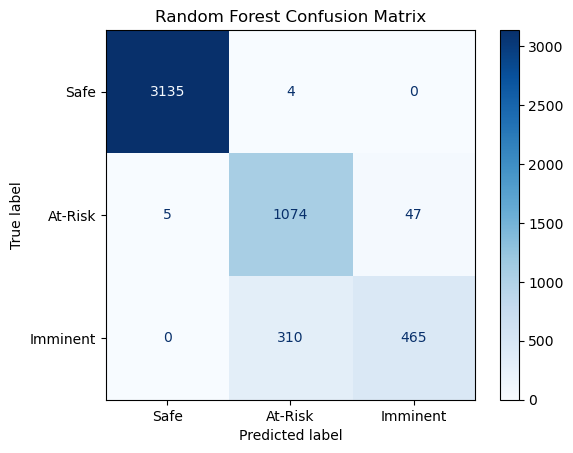

In [13]:
# Final evaluation and confusion matrix

final_model = rf_model
final_predictions = rf_pred

print(classification_report(y_test, final_predictions))

cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=["Safe", "At-Risk", "Imminent"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Safe", "At-Risk", "Imminent"]
).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.show()

,feature,importance
8,num__days_of_cover,0.199925
9,num__days_of_cover_ratio,0.176687
3,num__reorder_gap,0.153685
10,num__stock_utilization,0.084354
1,num__closing_stock,0.052037
0,num__opening_stock,0.031259
7,num__sales_velocity_7d,0.025845
2,num__reorder_point,0.021795
15,num__supplier_reliability_risk,0.017797
21,num__day_of_month,0.017211


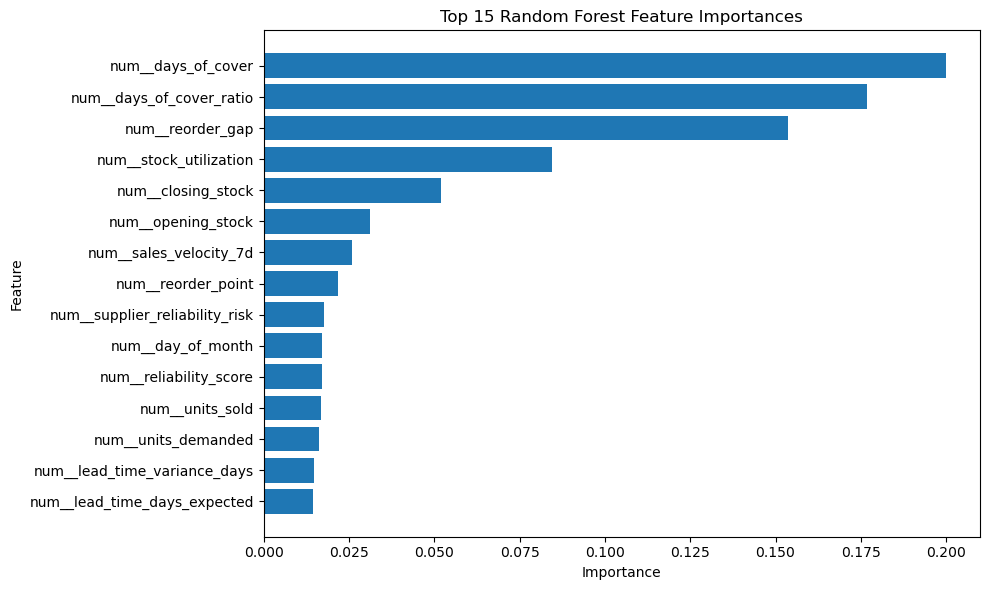

In [14]:
rf_feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": rf_feature_names,
    "importance": rf_model.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance.head(15))

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"].head(15)[::-1],
    feature_importance["importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [15]:
# Create recommendations from predictions

results = df.loc[test_mask, [
    "date", "store_id", "sku_id", "sku_name",
    "supplier_id", "supplier_name",
    "city_display", "days_of_cover",
    "reorder_gap"
]].copy()

results["actual_risk"] = y_test.values
results["predicted_risk"] = final_predictions

def recommend_action(risk):
    if risk == "Imminent":
        return "Urgent reorder / expedite supplier delivery"
    elif risk == "At-Risk":
        return "Monitor inventory and plan reorder"
    return "No immediate action"

results["recommended_action"] = results["predicted_risk"].apply(recommend_action)

results.to_csv("quickcart_model_predictions.csv", index=False)

display(
    results[results["predicted_risk"] == "Imminent"]
    .sort_values(["date", "days_of_cover"])
    .head(20)
)

,date,store_id,sku_id,sku_name,supplier_id,supplier_name,city_display,days_of_cover,reorder_gap,actual_risk,predicted_risk,recommended_action
10463,2026-10-24,ST01,SKU030,Instant Coffee 100g,SUP15,Regional Produce Hub,Mumbai,0.0,64.5,Imminent,Imminent,Urgent reorder / expedite supplier delivery
11183,2026-10-24,ST01,SKU032,Lassi 200ml,SUP15,Regional Produce Hub,Mumbai,0.0,190.7,Imminent,Imminent,Urgent reorder / expedite supplier delivery
16223,2026-10-24,ST01,SKU046,Garbage Bags 30pc,SUP07,CarePlus Wholesale,Mumbai,0.0,353.3,Imminent,Imminent,Urgent reorder / expedite supplier delivery
20543,2026-10-24,ST01,SKU058,Cup Cakes 4pc,SUP12,Bharat Staples Co,Mumbai,0.0,146.9,Imminent,Imminent,Urgent reorder / expedite supplier delivery
19523,2026-10-24,ST03,SKU055,White Bread 400g,SUP12,Bharat Staples Co,Bengaluru,0.0,126.0,Imminent,Imminent,Urgent reorder / expedite supplier delivery
19883,2026-10-24,ST03,SKU056,Brown Bread 400g,SUP12,Bharat Staples Co,Bengaluru,0.0,37.7,Imminent,Imminent,Urgent reorder / expedite supplier delivery
10553,2026-10-24,ST04,SKU030,Instant Coffee 100g,SUP15,Regional Produce Hub,Bengaluru,0.0,41.8,Imminent,Imminent,Urgent reorder / expedite supplier delivery
9503,2026-10-24,ST05,SKU027,Orange Juice 1L,SUP04,Sunrise Agro Traders,Delhi,0.0,18.2,Imminent,Imminent,Urgent reorder / expedite supplier delivery
19943,2026-10-24,ST05,SKU056,Brown Bread 400g,SUP12,Bharat Staples Co,Delhi,0.0,18.2,Imminent,Imminent,Urgent reorder / expedite supplier delivery
21383,2026-10-24,ST05,SKU060,Croissant 2pc,SUP10,Daily Bakes Supply,Delhi,0.0,135.0,Imminent,Imminent,Urgent reorder / expedite supplier delivery


In [16]:
joblib.dump(final_model, "quickcart_stockout_model.pkl")
joblib.dump(features, "quickcart_features.pkl")

print("Model and feature list saved successfully.")

Model and feature list saved successfully.


# QuickCart Stockout Risk Prediction — Final Summary

## Objective

Predict stockout risk for QuickCart inventory and identify products, stores, and suppliers that require inventory attention.

## Dataset

- 21,600 inventory records
- October 2026 daily inventory data
- Five CSV datasets joined for analysis
- Target classes: Safe, At-Risk, and Imminent

## Data Quality and Feature Engineering

- Corrected inconsistent `city_display` casing.
- Explicitly treated supplier reliability value `N/A` as missing.
- Joined store, SKU, supplier, event, and inventory data.
- Created reorder gap, days-of-cover ratio, recent reorder, calendar, event, and supplier-risk features.
- Used category encoding and supplier reliability information.

## Validation Strategy

A time-based split was used to avoid leakage from repeated store-SKU combinations:

- Training data: October 1–23, 2026
- Test data: October 24–30, 2026

## Model Comparison

| Model | Accuracy | Imminent Precision | Imminent Recall | Imminent F1 |

| Majority Baseline | 62.3% | 0.0% | 0.0% | 0.0% |
| Logistic Regression | 79.5% | 44.2% | 99.4% | 61.1% |
| Random Forest | 92.7% | 90.8% | 60.0% | 72.3% |

## Final Model

Random Forest was selected as the final model because it achieved the strongest overall accuracy, precision, and Imminent F1-score.

Its Imminent recall is 60.0%, which means it identifies 60% of true imminent stockout cases. Logistic Regression achieved higher recall but produced substantially more false alerts.

## Business Insights

- Festival-week Imminent risk was 23.31%, compared with 9.51% on non-festival days.
- Perishable products had higher Imminent risk than non-perishable products.
- Inventory cover, reorder position, demand, supplier reliability, and event conditions are important for stockout risk.
- The model's feature-importance chart identifies the strongest predictors.

## Business Recommendations

- Immediately replenish SKUs predicted as Imminent.
- Monitor At-Risk products and create reorder plans before stockout.
- Give extra attention to perishable products during festival and promotion periods.
- Monitor suppliers with lower reliability scores and higher lead-time variability.
- Use the saved prediction file to prioritize stores, SKUs, and suppliers for action.